In [1]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats
import scipy.linalg as linalg
from src.pt import *
import ot


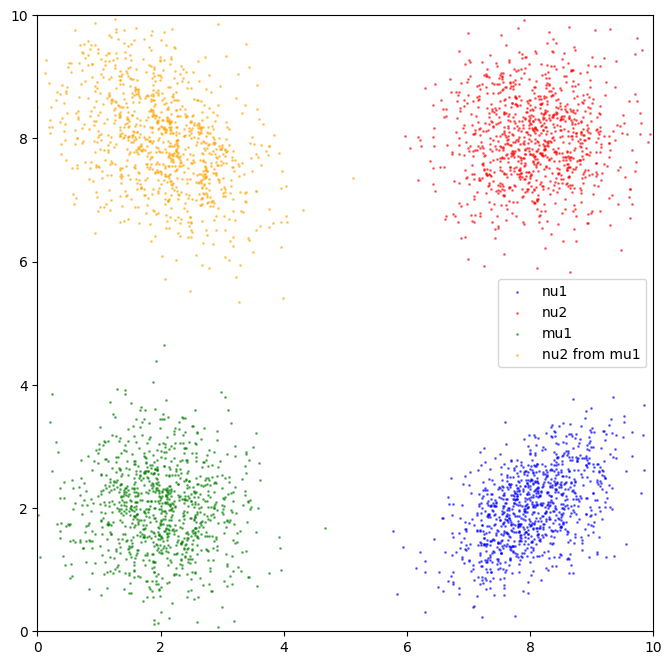

In [3]:
# test with samples from normal
n_samples_nu_1 = 1000
n_samples_nu_2 = 1000
n_samples_mu_1 = 1000

mean_nu1 = np.array([8, 2])
sigma_nu1 = np.array([[0.4, 0.2], [0.2, 0.4]])

mean_nu2 = np.array([8, 8])
sigma_nu2 = np.array([[0.5, 0.0], [0.0, 0.5]])

mean_mu1 = np.array([2, 2])
sigma_mu1 = np.array([[0.5, 0.0], [0.0, 0.5]])

# sample n_samples from nu_1, mu_1 and nu_2
nu1_samples = np.random.multivariate_normal(mean_nu1, sigma_nu1, size=n_samples_nu_1)
nu2_samples = np.random.multivariate_normal(mean_nu2, sigma_nu2, size=n_samples_nu_2)
mu1_samples = np.random.multivariate_normal(mean_mu1, sigma_mu1, size=n_samples_mu_1)

# obtain logmap from nu1 to nu2 and from nu1 to mu1
nu1_measure = EmpiricalMeasure(nu1_samples, np.ones(n_samples_nu_1) / n_samples_nu_1)
nu2_measure = EmpiricalMeasure(nu2_samples, np.ones(n_samples_nu_2) / n_samples_nu_2)
mu1_measure = EmpiricalMeasure(mu1_samples, np.ones(n_samples_mu_1) / n_samples_mu_1)

tangent_nu1_nu2 = wasserstein_logmap(nu1_measure, nu2_measure)
tangent_nu1_mu1 = wasserstein_logmap(nu1_measure, mu1_measure)

# parallel transport tangent_nu1_nu2 from nu1 to mu1
tangent_nu2_mu1 = tangent_nu1_nu2.parallel_transport(nu1_measure, mu1_measure, n=10)
# compute the exponential map of the transported tangent at mu1
nu2_from_mu1 = tangent_nu2_mu1.wasserstein_expmap()

# visualize by plotting and color-coding the measures (no tangents)
plt.figure(figsize=(8, 8))
plt.scatter(nu1_measure.locs[:, 0], nu1_measure.locs[:, 1], color='blue', alpha=0.5, label='nu1', s=1)
plt.scatter(nu2_measure.locs[:, 0], nu2_measure.locs[:, 1], color='red', alpha=0.5, label='nu2', s=1)
plt.scatter(mu1_measure.locs[:, 0], mu1_measure.locs[:, 1], color='green', alpha=0.5, label='mu1', s=1)
plt.scatter(nu2_from_mu1.locs[:, 0], nu2_from_mu1.locs[:, 1], color='orange', alpha=0.5, label='nu2 from mu1', s=1)
# set axis limits for better visualization
plt.xlim(0, 10)
plt.ylim(0, 10)
# set aspect ratio to equal for proper distance visualization
plt.gca().set_aspect('equal', adjustable='box')
plt.legend()



In [12]:
print(tangent_nu1_mu1.locs_src[0:15])
print(mu1_measure.locs[0:15])

[[ 8.72748917  2.52499368]
 [ 6.37580235  0.45202306]
 [ 6.79236768  2.51273868]
 [ 8.12212261  2.11201791]
 [10.01014778  2.9574175 ]
 [ 7.87389789  0.83592028]
 [ 8.30459922  1.12000505]
 [ 6.53779808  2.55135464]
 [ 7.17445074  2.85465856]
 [ 6.3857523   2.17856825]
 [ 7.74887875  2.277183  ]
 [ 8.56020153  2.42274745]
 [ 8.34781706  2.36527641]
 [ 8.23305278  2.80913343]
 [ 8.12831328  1.87950012]]
[[1.35266494 1.6987689 ]
 [2.00493013 2.48644828]
 [2.9956508  2.39357299]
 [2.68201909 2.30885046]
 [2.30303482 2.16720793]
 [1.8864923  2.49163261]
 [2.28977974 2.32137322]
 [1.56639603 2.28612148]
 [2.95882985 2.92537747]
 [1.29264305 2.81162208]
 [2.10578084 1.58053968]
 [1.49433615 0.58579194]
 [2.5248867  2.09169871]
 [2.77668778 0.91523914]
 [1.44059904 0.63774064]]


In [5]:
locs = np.array([[0.0], [1.0]])
weights = np.array([0.5, 0.5])
base = EmpiricalMeasure(locs, weights)

vels = np.array([[0.5], [-0.5]])
tangent = W2EuclideanTangent(locs_src = locs, vels = vels)

moved = wasserstein_expmap(base, tangent)
logmap = wasserstein_logmap(moved, base)


print("Base locations:", base.locs)
print("Base weights:", base.weights)
print("Moved locations:", moved.locs)
print("Moved weights:", moved.weights)
print("Logmap vels:", logmap.vels)
print("Logmap coupling:", logmap.coupling)


Base locations: [[0.]
 [1.]]
Base weights: [0.5 0.5]
Moved locations: [[0.5]]
Moved weights: [1.]
Logmap vels: None
Logmap coupling: [[0.5 0.5]]


Tangent locs_src: [[0.5]]
Tangent vels: None
Tangent locs_dst: [[0.]
 [1.]]
Tangent coupling: [[0.5 0.5]]


(-0.1, 1.5)

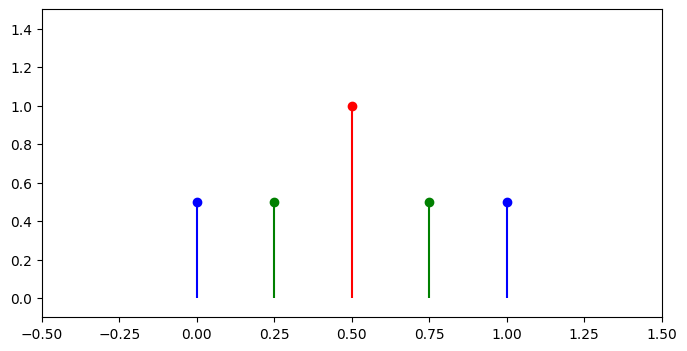

In [79]:
# compute the logarithmic map of dst at src
src_locs = np.array([[0.5]])
src_weights = np.array([1.0])

dst_locs = np.array([[0.0], [1.0]])
dst_weights = np.array([0.5, 0.5])

src = EmpiricalMeasure(src_locs, src_weights)
dst = EmpiricalMeasure(dst_locs, dst_weights)
tangent = wasserstein_logmap(src, dst)

tan_halfway = interp_tan_coupling(tangent, t_0=0.0, t_1=0.5)
interp = wasserstein_expmap(src, tan_halfway)
interp_locs = interp.locs
interp_weights = interp.weights

print("Tangent locs_src:", tangent.locs_src)
print("Tangent vels:", tangent.vels)
print("Tangent locs_dst:", tangent.locs_dst)
print("Tangent coupling:", tangent.coupling)

# plot empirical measures as dirac deltas
plt.figure(figsize=(8, 4))
plt.stem(base.locs.flatten(), base.weights, linefmt='b-', markerfmt='bo', basefmt=' ', label='Src Measure')
plt.stem(interp_locs.flatten(), interp_weights, linefmt='g-', markerfmt='go', basefmt=' ', label='Interpolated Measure')
plt.stem(moved.locs.flatten(), moved.weights, linefmt='r-', markerfmt='ro', basefmt=' ', label='Target Measure')
plt.xlim(-0.5, 1.5)
plt.ylim(-0.1, 1.5)